In [2]:
# Classfication model for NPAs - loan_borowwer_data.csv

import seaborn as sns
import matplotlib. pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("loan_borowwer_data.csv")
x = df.iloc[:,0:13]   # variables affecting the label - leaving out address and other strings because they may not affect the label
y = df["not.fully.paid"]
label_encoder = LabelEncoder()
encoded_data = label_encoder.fit_transform(x['purpose'])
x['purpose'] = encoded_data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

      credit.policy  purpose  int.rate  installment  log.annual.inc    dti  \
0                 1        2    0.1189       829.10       11.350407  19.48   
1                 1        1    0.1071       228.22       11.082143  14.29   
2                 1        2    0.1357       366.86       10.373491  11.63   
3                 1        2    0.1008       162.34       11.350407   8.10   
4                 1        1    0.1426       102.92       11.299732  14.97   
...             ...      ...       ...          ...             ...    ...   
9573              0        0    0.1461       344.76       12.180755  10.39   
9574              0        0    0.1253       257.70       11.141862   0.21   
9575              0        2    0.1071        97.81       10.596635  13.09   
9576              0        4    0.1600       351.58       10.819778  19.18   
9577              0        2    0.1392       853.43       11.264464  16.28   

      fico  days.with.cr.line  revol.bal  revol.util  inq.last.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(x_train, y_train)
pred_y = lr.predict(x_test)
print("Accuracy :")
acc = accuracy_score(y_test,pred_y)
print(acc)

Accuracy :
0.837160751565762


C:\Users\SiyaPransh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 1000x800 with 0 Axes>

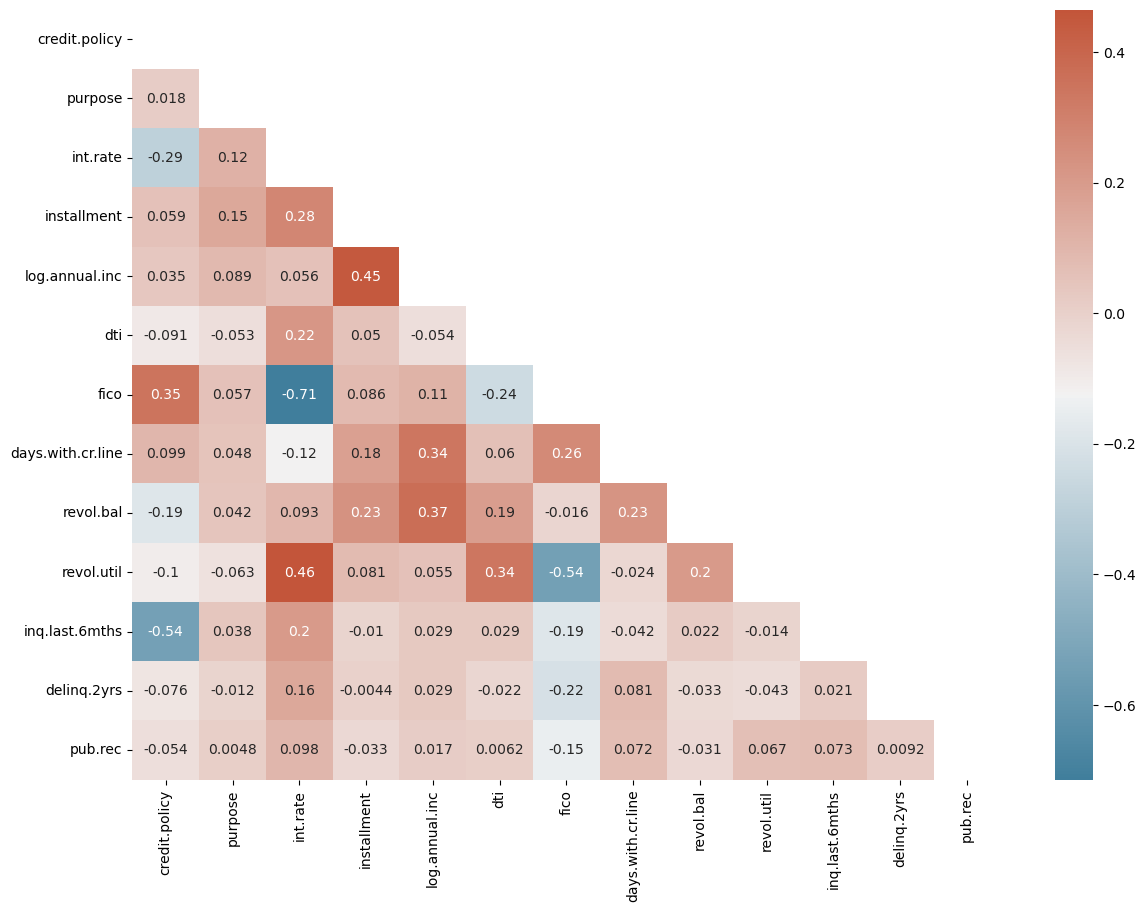

In [4]:
# Calculate the correlation matrix
import numpy as np
corr = x.corr()
# Create the heatmap
plt.figure(figsize = (10,8))
f, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, cmap = cmap, mask =  mask)
plt.show()

In [6]:
# Trying correlation matrix interpretaion. Removed int.rate & inq.last.6months

x = x[['credit.policy','purpose','installment','log.annual.inc','dti','fico','days.with.cr.line','revol.bal','revol.util','delinq.2yrs','pub.rec']]
y = y
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(x_train, y_train)
pred_y = lr.predict(x_test)
print("Accuracy :")
acc = accuracy_score(y_test,pred_y)
print(acc)
# Accuracy did not change much after removing above fields

Accuracy :
0.8335073068893528


C:\Users\SiyaPransh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
